# **Trabajo práctico final: Obtención y procesamiento de imágenes Sentinel-2 en la nube para la estimación de Clorofila-a en el Embalse San Roque (Córdoba, Argentina)**

**Materia:** Procesamiento digital de imágenes satelitales y sistemas de información geográfica (Maestría en Aplicaciones de Información Espacial, I. Gulich)

**Docentes:** Dr. Santiago Seppi y Dr. Mario Sgró

**Alumno:** Franco David Barrionuevo

**Año:** 2026

## Introducción y problemática

La eutrofización es un proceso mediante el cual aumenta la producción primaria de un cuerpo de agua como consecuencia del ingreso de cantidades elevadas de materia orgánica y nutrientes, entre ellos fósforo y nitrógeno. Como resultado, bajo condiciones adecuadas, puede producirse un incremento de la biomasa algal, lo que suele denominarse floración (o *bloom*) algal (Wetzel, 2001).

La clorofila-a (Cl-a) es un pigmento característico de las especies vegetales y de las microalgas. La medición de su concentración se utiliza como un indicador de la biomasa algal, así como del estado trófico de un cuerpo de agua (Carlson, 1977).

El Emblase San Roque es un dique artificial ubicado en la ciudad de Villa Carlos Paz, provincia de Córdoba, Argentina. El dique se localiza aproximadamente a los 31.37° S y 64.47° O, a una altitud de 643 m s.n.m. Las frecuentes condiciones de eutrofización que sufre favorecen la ocurrencia de una elevada producción de algas. Debido a su gran extensión, realizar un muestreo convencional para evaluar su estado no resulta suficiente. Ante esta situación, el empleo de datos satelitales para su monitoreo surge como una alternativa que ha mostrado resultados satisfactorios en este embalse (Ferral et al., 2017).

## Metodología

### Estimación concentración de clorofila-a y estado trófico

El modelo empleado fue el definido por German et al. (2021), el cual se obtuvo mediante el ajuste de datos de reflectancia en las bandas del rojo (Red) e infrarrojo cercano (NIR) de escenas de Sentinel-2 con mediciones *in-situ* de la concentración de clorofila-a (Ecuación 1). La alta absorción de este pigmento alrededor de los 670 nm y al pico de reflectancia de las células algales alrededor de los 700 nm, permite laborar modelos semiempíricos que relacionan la reflectancia en dichos rangos del espectro electromagnético, medida por los sensores a bordo de los satélites, con datos de campo de concentración del pigmento.

\begin{equation}
log(Conc. Cl-a) = 0.33*(B5/B4) + 3.82
\end{equation}

El estado trófico fue evaluado a través del Índice de Estado Trófico (TSI, por sus siglas en inglés) propuesto por Carlson. Este fue computado a partir de la Ecuación 2, la cual calcula el índice a partir de la concentración de clorofila-a estimada. De acuerdo con este índice, valores entre 0 y 20 corresponden a un estado *ultraoligotrófico*; entre 20 y 40, *oligotrófico*; entre 40 y 50, *mesotrófico*; entre 50 y 70, *eutrófico*; y superiores a 70, *hipertrófico*.

\begin{equation}
TSI = 9.81 \ln(\text{Cl-a}) + 30,6
\end{equation}

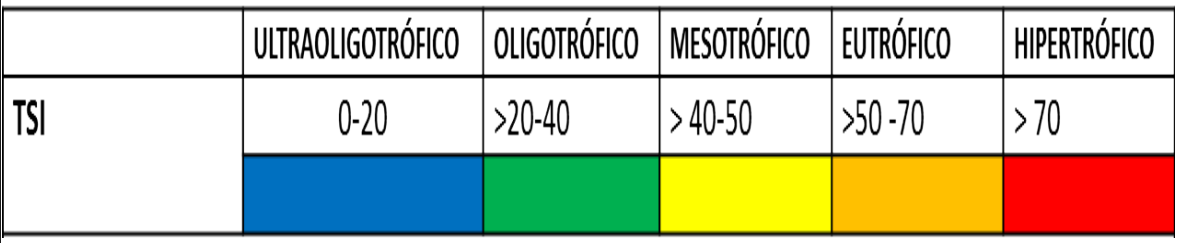

### Adquisición de datos de Sentinel-2 L2A mediante STAC

El SpatioTemporal Asset Catalog (STAC) es una familia de especificaciones que permite estandarizar la estructura y consulta de metadatos geoespaciales, facilitando el acceso y la interoperabilidad de datos relacionados con la Tierra. Un *asset* espaciotemporal es cualquier archivo que contiene información sobre la Tierra asociada a una ubicación y un momento determinados. 

Algunas de las caracteristicas principales incluyen:

- Interoperabilidad: permite estandarizar y consultar metadatos provenientes de diferentes fuentes y sensores, como Landsat 8 y Sentinel-2.
- Acceso directo a datos: los metadatos pueden incluir enlaces directos a los archivos almacenados en servicios como Amazon S3.
- Búsqueda eficiente: facilita la búsqueda de grandes colecciones de datos mediante áreas de interés espaciales y temporales.

La API de STAC API permite consultar catálogos STAC mediante una API web, facilitando la búsqueda de datos geoespaciales. Por ejemplo, permite hacer un *request* de todos los productos que intersecten un área determinada y hayan sido adquiridos durante un período específico. Para este trabajo, se empleó la API de STAC de Python, que permitió explorar y posteriormente descargar las escenas del producto L2A de Sentinel-2 a través del catalogo de [Earth Search by Element 84](https://stacindex.org/catalogs/earth-search#/), el cual se haya alojado en Amazon Web Services. 

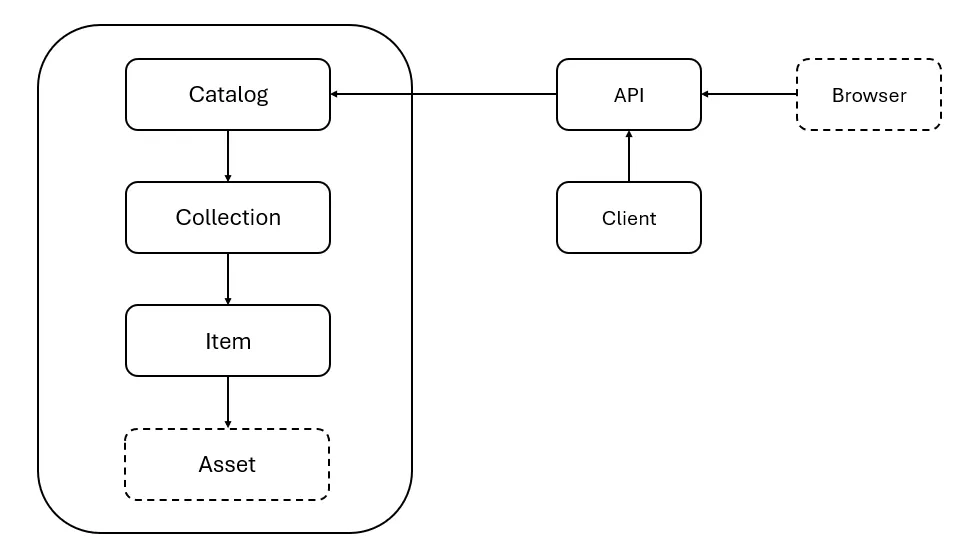


### Flujo de procesamiento

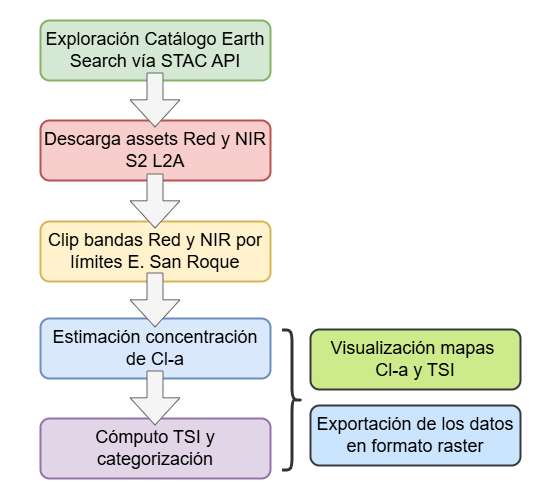

## Implementación del flujo de trabajo

### Configuración de librerías y carpetas

In [1]:
# @title Installación de paquetes en el entorno
# --
!pip install pystac-client --quiet

# --
!pip install 'localtileserver<1.0.0' --quiet # A Mayo del 2025, utilizamos una versión anterior de tilserver. La versión actualizda no muestra los tifs
!pip install leafmap --quiet

# Importo funciones.py desde GitHub
!wget -O funciones.py \
https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_clorfS2/data/funciones.py --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.

In [3]:
# Importamos librerías
import os
import numpy as np
import leafmap
from matplotlib.colors import ListedColormap, BoundaryNorm

# Importamos funciones.py
import funciones as fn

In [4]:
# Directorio donde se guardarán los archivos
ASSETS_FOLDER = "assets"
os.makedirs(ASSETS_FOLDER, exist_ok=True)

# Directorio donde se guardarán los archivos
MAPS_FOLDER = "maps"
os.makedirs(MAPS_FOLDER, exist_ok=True)

### Acceso al catálogo mediante API STAC

**Configuración de los parámetros de búsqueda**

In [ ]:
DATE_INI = '2026-04-01' # Fecha inicio de búsqueda
DATE_END = '2026-05-01' # Fecha de fin de búsqueda
CV = 10 # Cloud cover (%) mínimo

**Búsqueda de ítems (escenas de Sentinel-2) según los parámetros de búsqueda**

In [ ]:
# Obtención de los ítems  de S2 según los parámetros de búsqueda
ITEMS = fn.explore_s2_items(DATE_INI, DATE_END, CV)

# Visualización en formato dataframe de los ítems hallados
fn.df_items(ITEMS)

,Fecha,Plataforma,Cloud Cover (%)
0,2026-05-01,sentinel-2b,0.824116
1,2026-04-23,sentinel-2c,0.041015
2,2026-04-16,sentinel-2c,0.001015
3,2026-04-03,sentinel-2c,7.946352


**Selección del ítem para la fecha YYYY-MM-DD y plataforma S2X**

In [ ]:
# Selección del ítem según el índice del dataframe
ITEM_ID = 1

### Descarga de los assets, cómputo de Cl-a y TSI, y exportación

In [ ]:
# Ejecuta procesamiento de las bandas, computo de cl-a y TSI, y exportación de los resultados
dict_maps, dict_paths = fn.run_chla_s2(ITEMS, ITEM_ID, ASSETS_FOLDER, MAPS_FOLDER)

RUN PASO 1: DESCARGA DE LOS ASSETS DE SENTINEL-2
Descargando nir -> assets/S2c_2026-04-23_nir.tif ...
Descarga completada: assets/S2c_2026-04-23_nir.tif
Descargando red -> assets/S2c_2026-04-23_red.tif ...
Descarga completada: assets/S2c_2026-04-23_red.tif
Descargas completadas.
END PASO 1


RUN PASO 2: CLIPEADO DE LAS BANDAS
END PASO 2


RUN PASO 3: CÓMPUTO DE LOS MAPAS DE CHL-A Y CARLSON INDEX
END PASO 3


RUN PASO 4: GUARDADO DE LOS MAPAS COMO EN FORMATO .TIF
END PASO 4


### Visualización de los mapas de Cl-a y TSI con Matplotlib

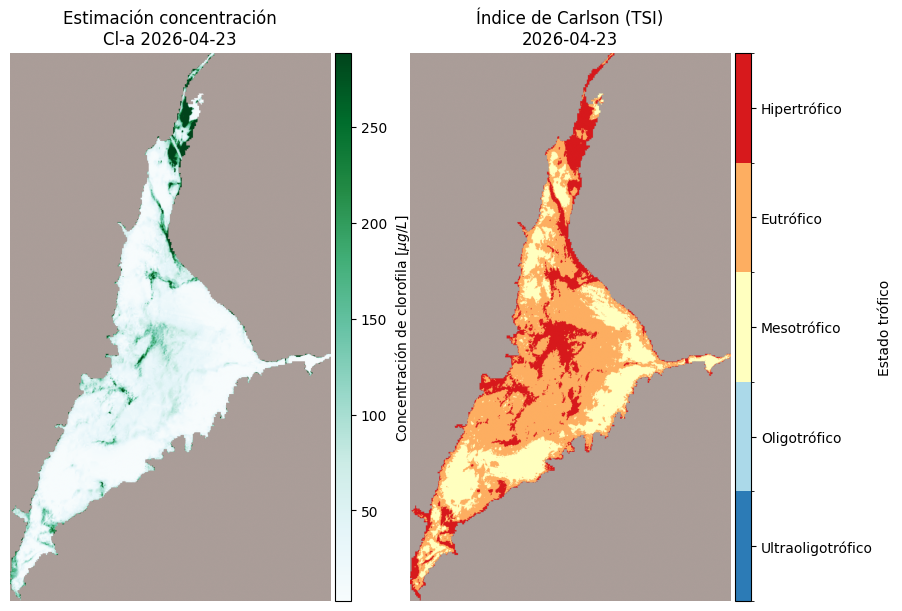

In [ ]:
# 
fn.plot_maps(dict_maps['chla_map'], dict_maps['tsi_map'], dict_maps['date'])

### Visualización interactiva de los mapas de Cl-a y TSI con Leafmap

In [26]:
m = leafmap.Map(zoom= 20, basemap="Esri.WorldImagery") #center=[-32.866, -60.324]

# Agrega la capa al mapa
m.add_raster(
    dict_paths['chla_path'],
    layer_name="chl_a",
    palette="Greens",
    nodata=np.nan,
    colormap=True,
)

#m_merge.add_gdf(polygon, layer_name="Bounding Box", style={"color": "red", "weight": 2, "fillOpacity": 0})

m.add_colormap(
    cmap="Greens",
    vmin=np.nanpercentile(dict_maps['chla_map'], 1),
    vmax=np.nanpercentile(dict_maps['chla_map'], 99),
    label="Chlorophyll-a"
)


# Colors for the 5 TSI classes
colors = [
    "#2c7bb6",
    "#abd9e9",
    "#ffffbf",
    "#fdae61",
    "#d7191c"
]

cmap = ListedColormap(colors)
#cmap.set_bad(color="#6B544C92")

# Classes: 0, 1, 2, 3, 4
bounds = np.arange(-0.5, 5.5, 1)
norm = norm = BoundaryNorm(bounds, cmap.N)

m.add_raster(
    dict_paths['tsi_path'],
    layer_name="TSI",
    colormap=cmap,
    vmin=0,
    vmax=4,
    norm=norm,
    nodata=np.nan
)

m.add_legend(
    title="Índice de Carlson (TSI)",
    labels=[
        "Ultraoligotrófico",
        "Oligotrófico",
        "Mesotrófico",
        "Eutrófico",
        "Hipertrófico"
    ],
    colors=colors
)

# Muestra el mapa
m

Map(center=[-31.367729, -64.4654885], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…